In [14]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import math

In [3]:
# Set the datasets (From tensorflow document originally)
fashion_mnist = tf.keras.datasets.fashion_mnist

In [4]:
(x_train, y_train),(x_test, y_test) = fashion_mnist.load_data()

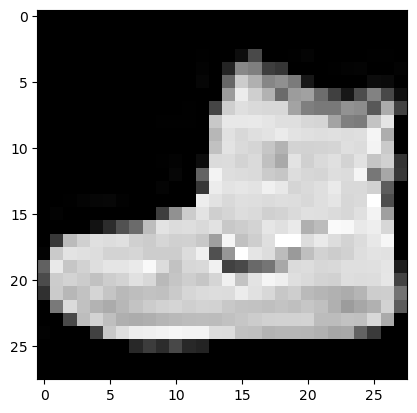

In [5]:
plt.imshow(x_train[0], cmap='gray')

In [36]:
# label_ids = [2, 1, 8, 4, 1, 9, 2, 2, 0, 2]
label_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

x_train = x_train.astype("uint8") / 255
x_test = x_test.astype("uint8") / 255

y_train_tf = tf.keras.utils.to_categorical(y_train, 10)
y_test_tf = tf.keras.utils.to_categorical(y_test, 10)

In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
# Filter Layers
model = tf.keras.Sequential()

# Input layer
input_shape = (28, 28, 1)
model.add(tf.keras.Input(shape=input_shape))

# Hidden layers
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(5, 5), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(512, activation="relu"))

model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Dense(256, activation="relu"))
model.add(tf.keras.layers.Dense(128, activation="relu"))
model.add(tf.keras.layers.Dense(64, activation="relu"))
model.add(tf.keras.layers.Dense(32, activation="relu"))
model.add(tf.keras.layers.Dense(16, activation="relu"))

# Output layer
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,298 (3.87 MB)

 Trainable params: 1,014,298 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.fit(
  x_train,
  y_train_tf,
  batch_size=1000, # เรียนรู้ที่ละกี่ภาพต่อ 1 รอบ
  epochs=5,
  validation_split=0.2
)

Epoch 1/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 207ms/step - accuracy: 0.4289 - loss: 1.4436 - val_accuracy: 0.7106 - val_loss: 0.7964
Epoch 2/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 211ms/step - accuracy: 0.7434 - loss: 0.6796 - val_accuracy: 0.7849 - val_loss: 0.5616
Epoch 3/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 220ms/step - accuracy: 0.7976 - loss: 0.5370 - val_accuracy: 0.8175 - val_loss: 0.4848
Epoch 4/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.8308 - loss: 0.4617 - val_accuracy: 0.8456 - val_loss: 0.4242
Epoch 5/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - accuracy: 0.8512 - loss: 0.4096 - val_accuracy: 0.8575 - val_loss: 0.3874


In [12]:
model.evaluate(x_test, y_test_tf)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8495 - loss: 0.4011


[0.4010893702507019, 0.8495000004768372]

In [13]:
result = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [26]:
label_names[
  np.argmax(result[5])
]

'Trouser'

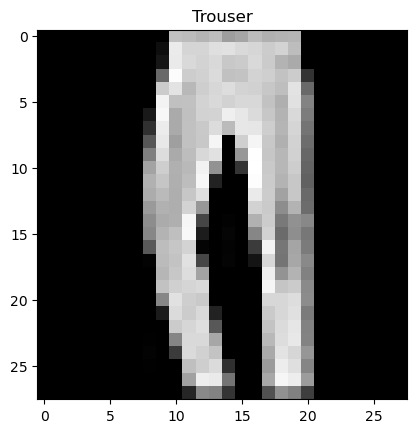

In [23]:
idx = 5

plt.title(label_names[y_test[idx]])
plt.imshow(x_test[idx], cmap='gray')

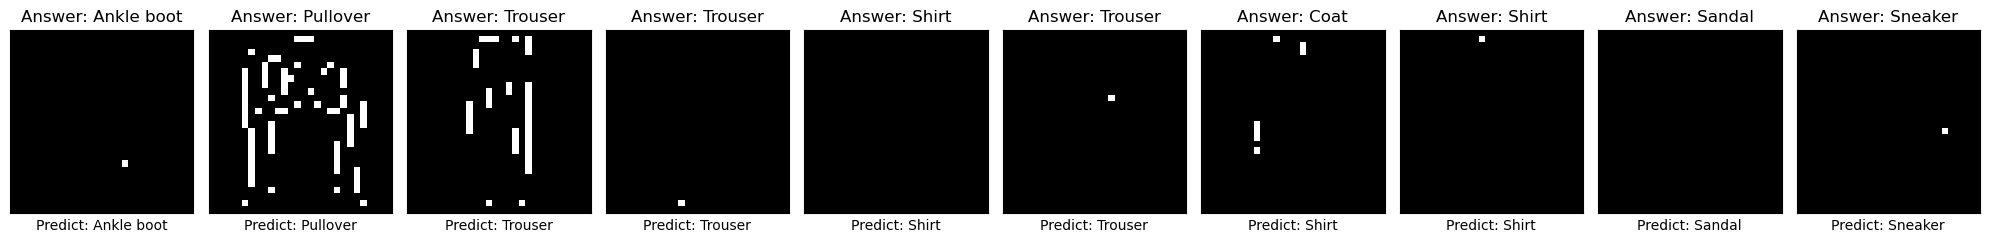

In [37]:
plt.figure(figsize=(20, 10))

for i in range(10):

  predict = label_names[np.argmax(result[i])]
  answer = label_names[np.argmax(y_test_tf[i])]

  plt.subplot(1, 10, i + 1)
  plt.title(f"Answer: {answer}")
  plt.xlabel(f"Predict: {predict}")
  plt.imshow(x_test[i], cmap='gray')
  
  plt.xticks([])
  plt.yticks([])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [45]:
y_pred = np.argmax(result, axis=1)

cm = confusion_matrix(
  y_test, y_pred, labels=range(len(label_names))
)

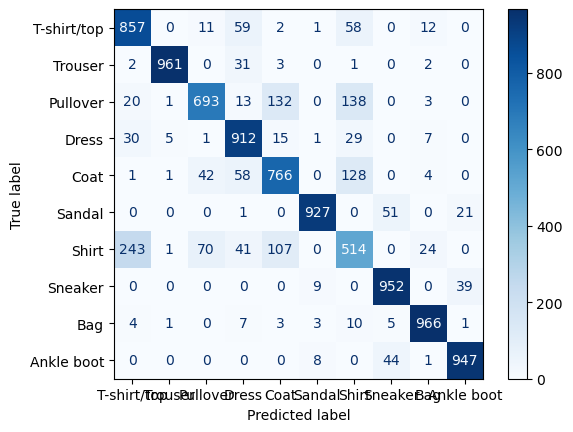

In [44]:
disp = ConfusionMatrixDisplay(
  confusion_matrix=cm, 
  display_labels=label_names,
)
disp.plot(cmap=plt.cm.Blues)
plt.show()
  